In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, precision_score, recall_score,
                             f1_score, accuracy_score, balanced_accuracy_score,
                             matthews_corrcoef, confusion_matrix, classification_report)

!pip install catboost
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)

conn = sqlite3.connect('/content/drive/MyDrive/Tesis/FPA_FOD_20170508.sqlite')
df = pd.read_sql("SELECT * FROM Fires;", conn)
conn.close()

print(df.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
(1880465, 39)


Se importan las librerías de modelado y métricas, y se carga la tabla `Fires` completa
(1.880.465 registros). La semilla queda fija en 42 para que todos los resultados sean
reproducibles.

In [ ]:
dfc = df[df['STAT_CAUSE_DESCR'] != 'Missing/Undefined'].copy()
dfc['ES_NATURAL'] = (dfc['STAT_CAUSE_DESCR'] == 'Lightning').astype(int)

NUM = ['FIRE_YEAR', 'DISCOVERY_DOY', 'LATITUDE', 'LONGITUDE', 'FIRE_SIZE']
CAT = ['STATE', 'OWNER_DESCR', 'NWCG_REPORTING_AGENCY']
FEATS = NUM + CAT

dfc = dfc[FEATS + ['ES_NATURAL']].copy()

print(f"Registros: {len(dfc):,}")
print(f"Naturales: {dfc['ES_NATURAL'].sum():,}  ({dfc['ES_NATURAL'].mean()*100:.2f}%)")
print(f"Antrópicos: {(1-dfc['ES_NATURAL']).sum():,}")
print()
print(f"Accuracy de predecir siempre 'Antrópico': {1 - dfc['ES_NATURAL'].mean():.4f}")

Registros: 1,713,742
Naturales: 278,468  (16.25%)
Antrópicos: 1,435,274

Accuracy de predecir siempre 'Antrópico': 0.8375


Se descartan los 166.723 registros sin causa reportada, porque no se conoce su etiqueta real.

La variable objetivo `ES_NATURAL` es binaria: vale 1 cuando la causa es Lightning (rayo,
la única causa natural del dataset) y 0 para las once causas antrópicas.

Se usan ocho variables predictoras: cinco numéricas (año, día del año, latitud, longitud y superficie quemada) y tres categóricas (estado, propietario del terreno y agencia reportante). Quedan fuera las columnas con más del 40% de valores faltantes, los identificadores y los códigos numéricos que duplican información ya presente.

In [ ]:
LOTES = [
    {'nombre': 'Lote 1', 'train_fin': 2001, 'test_ini': 2002, 'test_fin': 2004},
    {'nombre': 'Lote 2', 'train_fin': 2004, 'test_ini': 2005, 'test_fin': 2007},
    {'nombre': 'Lote 3', 'train_fin': 2007, 'test_ini': 2008, 'test_fin': 2011},
    {'nombre': 'Lote 4', 'train_fin': 2011, 'test_ini': 2012, 'test_fin': 2015},
]

for L in LOTES:
    tr = dfc[dfc['FIRE_YEAR'] <= L['train_fin']]
    te = dfc[(dfc['FIRE_YEAR'] >= L['test_ini']) & (dfc['FIRE_YEAR'] <= L['test_fin'])]
    print(f"{L['nombre']}:  train 1992-{L['train_fin']} ({len(tr):>9,})   "
          f"test {L['test_ini']}-{L['test_fin']} ({len(te):>8,})   "
          f"nat_train {tr['ES_NATURAL'].mean():.3f}  nat_test {te['ES_NATURAL'].mean():.3f}")

Lote 1:  train 1992-2001 (  699,265)   test 2002-2004 ( 197,579)   nat_train 0.169  nat_test 0.192
Lote 2:  train 1992-2004 (  896,844)   test 2005-2007 ( 261,543)   nat_train 0.174  nat_test 0.156
Lote 3:  train 1992-2007 (1,158,387)   test 2008-2011 ( 293,515)   nat_train 0.170  nat_test 0.143
Lote 4:  train 1992-2011 (1,451,902)   test 2012-2015 ( 261,840)   nat_train 0.164  nat_test 0.151


 Esquema de validación por lotes

En lugar de una única división entrenamiento/prueba, se emplea validación temporal progresiva (*walk-forward*): cada lote entrena con todos los años disponibles hasta un corte y evalúa sobre el bloque de años inmediatamente posterior.

| Lote | Entrenamiento | Prueba |
|---|---|---|
| 1 | 1992–2001 | 2002–2004 |
| 2 | 1992–2004 | 2005–2007 |
| 3 | 1992–2007 | 2008–2011 |
| 4 | 1992–2011 | 2012–2015 |

Este esquema responde dos cuestiones que una partición única no puede resolver.
 Primero, si el desempeño observado es estable o depende del corte elegido: al disponer de cuatro mediciones independientes se obtiene una media y una dispersión, no un valor aislado.

Segundo, si la relación entre las variables y la causa se mantiene a lo largo del tiempo o se degrada. La división es temporal y no aleatoria porque los incendios presentan autocorrelación espacial y temporal: una partición al azar colocaria en el conjunto de prueba registros casi
idénticos a los de entrenamiento (mismo estado, mismo año, misma agencia), lo que sobreestima el desempeño real del modelo.

In [ ]:
def preparar(train_fin, test_ini, test_fin, val_anios=2):
    val_ini = train_fin - val_anios + 1
    tr = dfc[dfc['FIRE_YEAR'] <= train_fin - val_anios].copy()
    va = dfc[(dfc['FIRE_YEAR'] >= val_ini) & (dfc['FIRE_YEAR'] <= train_fin)].copy()
    te = dfc[(dfc['FIRE_YEAR'] >= test_ini) & (dfc['FIRE_YEAR'] <= test_fin)].copy()

    for c in NUM:
        med = tr[c].median()
        for d in (tr, va, te):
            d[c] = d[c].fillna(med)
    for c in CAT:
        for d in (tr, va, te):
            d[c] = d[c].fillna('Desconocido').astype(str)

    return tr, va, te


def umbral_optimo(y_val, p_val):
    prec, rec, umb = precision_recall_curve(y_val, p_val)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return float(umb[np.nanargmax(f1[:-1])])


def metricas(y, p, umbral, modelo, lote):
    pred = (p >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        'Lote': lote,
        'Modelo': modelo,
        'AUC-ROC': roc_auc_score(y, p),
        'AUC-PR': average_precision_score(y, p),
        'Accuracy': accuracy_score(y, pred),
        'Bal.Acc': balanced_accuracy_score(y, pred),
        'Precision': precision_score(y, pred, zero_division=0),
        'Recall': recall_score(y, pred, zero_division=0),
        'Especif.': tn / (tn + fp),
        'F1': f1_score(y, pred, zero_division=0),
        'MCC': matthews_corrcoef(y, pred),
        'umbral': umbral,
    }

Funciones auxiliares

`preparar` construye los tres conjuntos de cada lote. Dentro del período de entrenamiento se reservan los dos últimos años como conjunto de validación, destinado exclusivamente a fijar el umbral de decisión. De este modo el conjunto de prueba no interviene en ninguna decisión previa a la evaluación final. La imputación de valores faltantes (mediana para
numéricas, categoría *Desconocido* para categóricas) se calcula siempre sobre el
entrenamiento y se aplica a los demás conjuntos, para no filtrar información del futuro.

`umbral_optimo` selecciona el punto de corte que maximiza el F1 sobre la validación.

`metricas` calcula el conjunto completo de indicadores. Se incorporan AUC-PR,exactitud balanceada y MCC.

 Modelo de referencia: regresión logística

Antes de recurrir a algoritmos de mayor complejidad se establece un baseline con
regresión logística, el modelo lineal estándar para clasificación binaria. Su función es fijar el piso de desempeño: cualquier modelo más sofisticado debe superarlo de forma clara para justificar su costo computacional y su menor interpretabilidad.

Las variables numéricas se estandarizan, ya que la regresión logística es sensible a la escala. Las categóricas se codifican mediante one-hot, procedimiento que no utiliza la variable objetivo y por lo tanto no introduce filtración de información. El parámetro `class_weight='balanced'` compensa el desbalance de clases penalizando más los errores sobre la clase minoritaria.

In [ ]:
res_lr = []

for L in LOTES:
    tr, va, te = preparar(L['train_fin'], L['test_ini'], L['test_fin'])

    pipe = Pipeline([
        ('prep', ColumnTransformer([
            ('num', StandardScaler(), NUM),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), CAT),
        ])),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
    ])

    pipe.fit(tr[FEATS], tr['ES_NATURAL'])
    p_va = pipe.predict_proba(va[FEATS])[:, 1]
    u = umbral_optimo(va['ES_NATURAL'], p_va)
    p_te = pipe.predict_proba(te[FEATS])[:, 1]

    res_lr.append(metricas(te['ES_NATURAL'].values, p_te, u, 'Regresión logística', L['nombre']))
    print(f"{L['nombre']}  AUC-ROC {res_lr[-1]['AUC-ROC']:.4f}  AUC-PR {res_lr[-1]['AUC-PR']:.4f}")

pd.DataFrame(res_lr).round(4)

Lote 1  AUC-ROC 0.9111  AUC-PR 0.7080
Lote 2  AUC-ROC 0.8521  AUC-PR 0.6188
Lote 3  AUC-ROC 0.8521  AUC-PR 0.5350
Lote 4  AUC-ROC 0.8839  AUC-PR 0.5938


,Lote,Modelo,AUC-ROC,AUC-PR,Accuracy,Bal.Acc,Precision,Recall,Especif.,F1,MCC,umbral
0,Lote 1,Regresión logística,0.9111,0.7080,0.8667,0.8513,0.6142,0.8264,0.8763,0.7046,0.6324,0.5544
1,Lote 2,Regresión logística,0.8521,0.6188,0.8670,0.8050,0.5571,0.7150,0.8951,0.6263,0.5532,0.6100
2,Lote 3,Regresión logística,0.8521,0.5350,0.8518,0.7890,0.4865,0.7011,0.8769,0.5744,0.5002,0.6242
3,Lote 4,Regresión logística,0.8839,0.5938,0.8628,0.8162,0.5333,0.7493,0.8831,0.6232,0.5539,0.6777


CatBoost

CatBoost es un algoritmo de *gradient boosting* sobre árboles de decisión desarrollado por Prokhorenkova et al. (2018). El boosting construye árboles en secuencia, donde cada árbol nuevo corrige los errores residuales de los anteriores; la predicción final es la suma ponderada de todos.

El número de iteraciones se determina mediante *early stopping* sobre el conjunto de
validación.

In [ ]:
res_cb = []

for L in LOTES:
    tr, va, te = preparar(L['train_fin'], L['test_ini'], L['test_fin'])
    cat_idx = [FEATS.index(c) for c in CAT]

    m = CatBoostClassifier(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=5,
        loss_function='Logloss',
        eval_metric='PRAUC',
        task_type='GPU',
        devices='0',
        cat_features=cat_idx,
        random_seed=SEED,
        early_stopping_rounds=80,
        use_best_model=True,
        verbose=False,
    )
    m.fit(tr[FEATS], tr['ES_NATURAL'], eval_set=(va[FEATS], va['ES_NATURAL']))

    p_va = m.predict_proba(va[FEATS])[:, 1]
    u = umbral_optimo(va['ES_NATURAL'], p_va)
    p_te = m.predict_proba(te[FEATS])[:, 1]

    r = metricas(te['ES_NATURAL'].values, p_te, u, 'CatBoost', L['nombre'])
    r['iters'] = m.get_best_iteration()
    res_cb.append(r)
    print(f"{L['nombre']}  AUC-ROC {r['AUC-ROC']:.4f}  AUC-PR {r['AUC-PR']:.4f}  iters {r['iters']}")

pd.DataFrame(res_cb).round(4)

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Lote 1  AUC-ROC 0.9494  AUC-PR 0.8566  iters 382


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Lote 2  AUC-ROC 0.9113  AUC-PR 0.7711  iters 558


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Lote 3  AUC-ROC 0.9179  AUC-PR 0.7086  iters 261


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Lote 4  AUC-ROC 0.9400  AUC-PR 0.7886  iters 996


,Lote,Modelo,AUC-ROC,AUC-PR,Accuracy,Bal.Acc,Precision,Recall,Especif.,F1,MCC,umbral,iters
0,Lote 1,CatBoost,0.9494,0.8566,0.9171,0.8791,0.7672,0.8174,0.9409,0.7915,0.7405,0.3169,382
1,Lote 2,CatBoost,0.9113,0.7711,0.9127,0.8378,0.7161,0.7288,0.9467,0.7224,0.6707,0.3309,558
2,Lote 3,CatBoost,0.9179,0.7086,0.8987,0.8181,0.6294,0.7052,0.9309,0.6652,0.6071,0.2796,261
3,Lote 4,CatBoost,0.9400,0.7886,0.9171,0.8390,0.7256,0.7270,0.9510,0.7263,0.6774,0.4031,996


Random Forest

Random Forest (Breiman, 2001) construye múltiples árboles de decisión sobre muestras aleatorias de los datos y de las variables, y promedia sus predicciones. A diferencia del boosting, los árboles se generan de forma independiente y en paralelo, lo que reduce la varianza del modelo.

(Falta hacer su prueba bien con el conjunto entero, gran posibilidad de quedarme con Catboost por comodidad) Dado el volumen de registros y que scikit-learn no dispone de aceleración por GPU, el entrenamiento se realiza sobre una muestra aleatoria del 30% del conjunto de entrenamiento de cada lote. Se trata de una restricción de cómputo documentada: el modelo principal utiliza la totalidad de los datos disponibles.

In [ ]:
res_rf = []

for L in LOTES:
    tr, va, te = preparar(L['train_fin'], L['test_ini'], L['test_fin'])
    tr_s = tr.sample(frac=0.30, random_state=SEED)

    pipe = Pipeline([
        ('prep', ColumnTransformer([
            ('num', 'passthrough', NUM),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), CAT),
        ])),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=18, min_samples_leaf=20,
            class_weight='balanced', random_state=SEED, n_jobs=-1))
    ])

    pipe.fit(tr_s[FEATS], tr_s['ES_NATURAL'])
    p_va = pipe.predict_proba(va[FEATS])[:, 1]
    u = umbral_optimo(va['ES_NATURAL'], p_va)
    p_te = pipe.predict_proba(te[FEATS])[:, 1]

    r = metricas(te['ES_NATURAL'].values, p_te, u, 'Random Forest', L['nombre'])
    res_rf.append(r)
    print(f"{L['nombre']}  AUC-ROC {r['AUC-ROC']:.4f}  AUC-PR {r['AUC-PR']:.4f}")

pd.DataFrame(res_rf).round(4)

Lote 1  AUC-ROC 0.9423  AUC-PR 0.8245
Lote 2  AUC-ROC 0.9026  AUC-PR 0.7402
Lote 3  AUC-ROC 0.9132  AUC-PR 0.6883
Lote 4  AUC-ROC 0.9295  AUC-PR 0.7490


,Lote,Modelo,AUC-ROC,AUC-PR,Accuracy,Bal.Acc,Precision,Recall,Especif.,F1,MCC,umbral
0,Lote 1,Random Forest,0.9423,0.8245,0.9088,0.8642,0.7488,0.7918,0.9367,0.7697,0.7133,0.6377
1,Lote 2,Random Forest,0.9026,0.7402,0.9060,0.8236,0.6961,0.7040,0.9433,0.7001,0.6443,0.6384
2,Lote 3,Random Forest,0.9132,0.6883,0.9053,0.7938,0.6788,0.6378,0.9498,0.6577,0.6032,0.6568
3,Lote 4,Random Forest,0.9295,0.7490,0.9062,0.8467,0.6662,0.7615,0.9319,0.7107,0.6571,0.6361


Comparación de modelos

In [ ]:
todos = pd.DataFrame(res_lr + res_cb + res_rf)
orden = ['Regresión logística', 'Random Forest', 'CatBoost']

resumen = (todos.groupby('Modelo')[['AUC-ROC','AUC-PR','Bal.Acc','F1','MCC']]
                .agg(['mean','std']).round(4).loc[orden])
print(resumen.to_string())
print()

pivot = todos.pivot(index='Lote', columns='Modelo', values='AUC-PR')[orden]
print("AUC-PR por lote")
print(pivot.round(4).to_string())

                    AUC-ROC          AUC-PR         Bal.Acc              F1             MCC        
                       mean     std    mean     std    mean     std    mean     std    mean     std
Modelo                                                                                             
Regresión logística  0.8748  0.0285  0.6139  0.0719  0.8154  0.0264  0.6321  0.0539  0.5599  0.0545
Random Forest        0.9219  0.0175  0.7505  0.0561  0.8321  0.0305  0.7095  0.0462  0.6545  0.0455
CatBoost             0.9296  0.0180  0.7812  0.0609  0.8435  0.0256  0.7263  0.0517  0.6739  0.0545

AUC-PR por lote
Modelo  Regresión logística  Random Forest  CatBoost
Lote                                                
Lote 1               0.7080         0.8245    0.8566
Lote 2               0.6188         0.7402    0.7711
Lote 3               0.5350         0.6883    0.7086
Lote 4               0.5938         0.7490    0.7886


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

AZUL     = '#1f4e79'
AZUL_CL  = '#5b8bbf'
TEAL     = '#2a6f6f'
BORDO    = '#7b2d3b'
NEUTRO   = '#4a5568'
TEXTO    = '#2d3748'

SEQ = LinearSegmentedColormap.from_list(
    'seq', ['#ffffff', '#dae3f0', '#a3bdd9', '#5b8bbf', '#1f4e79', '#12314a'])

DIV = LinearSegmentedColormap.from_list(
    'div', ['#1f4e79', '#8faed0', '#f7f7f7', '#c99aa3', '#7b2d3b'])

COLOR_MODELO = {
    'Regresión logística': NEUTRO,
    'Random Forest': TEAL,
    'CatBoost': AZUL,
}

In [ ]:
COLOR_TIPO = {
    'Antrópica': AZUL,
    'Natural': TEAL,
    'Sin causa': '#b8c2cc',
}

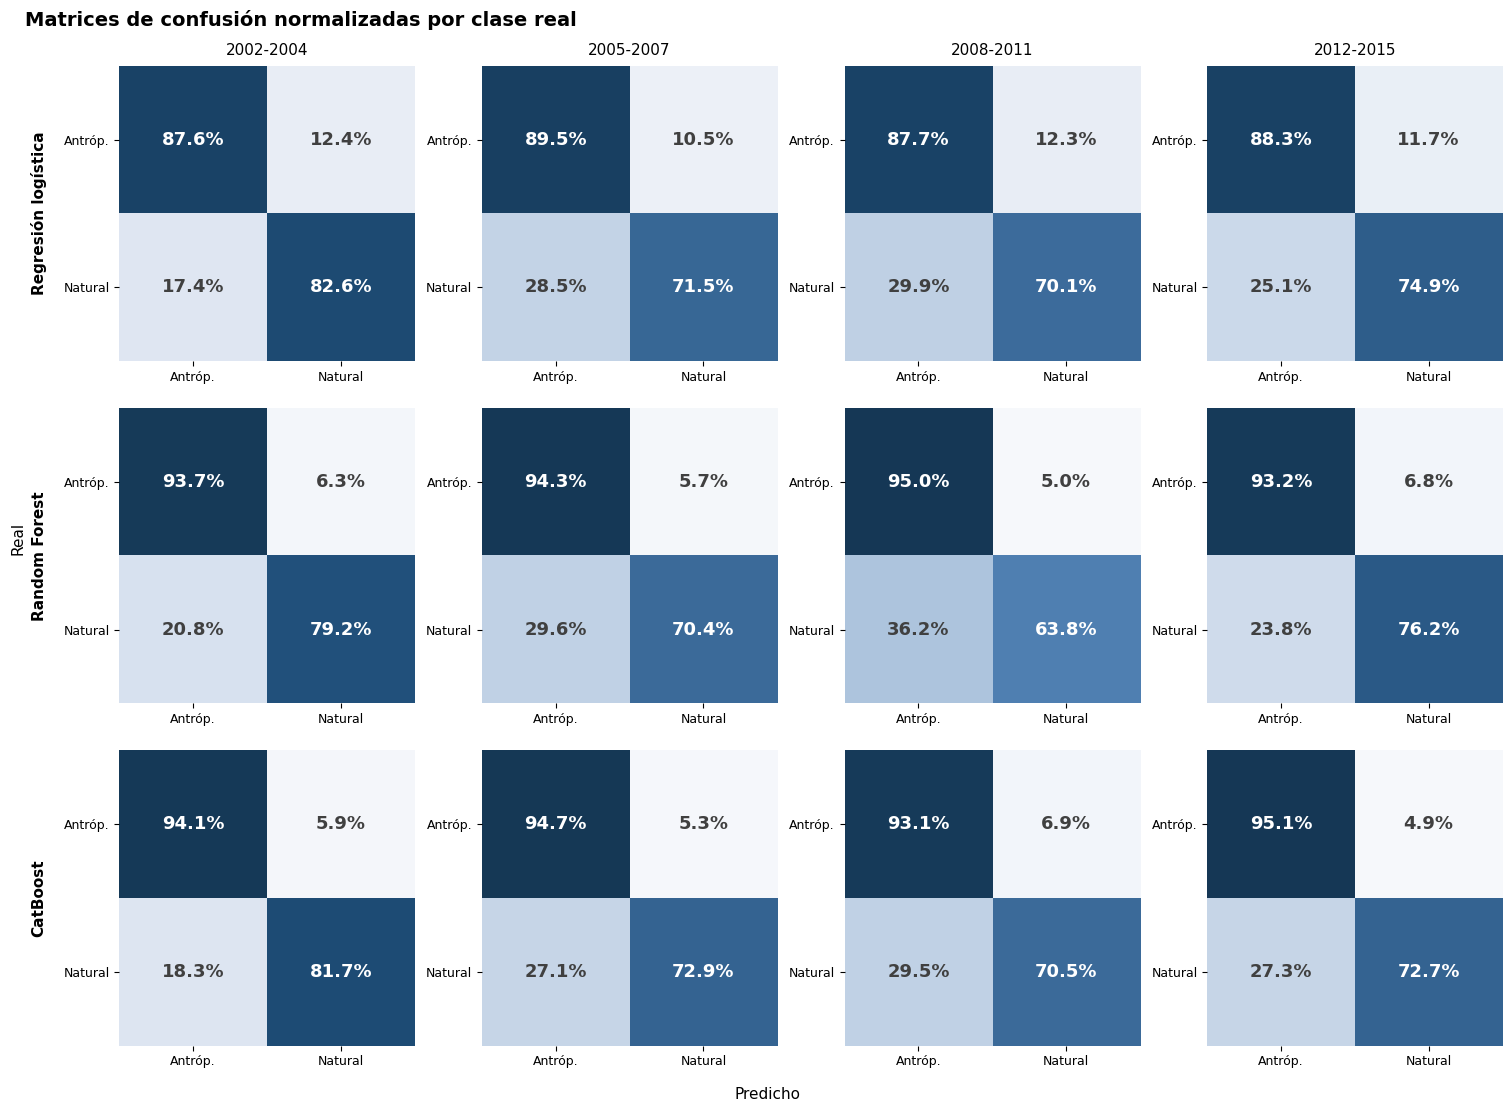

In [ ]:
resultados = {'Regresión logística': res_lr, 'Random Forest': res_rf, 'CatBoost': res_cb}

preds = {}
for L in LOTES:
    tr, va, te = preparar(L['train_fin'], L['test_ini'], L['test_fin'])
    preds[L['nombre']] = te['ES_NATURAL'].values

fig, axes = plt.subplots(3, 4, figsize=(15, 11))

for fila, modelo in enumerate(orden):
    for col, L in enumerate(LOTES):
        ax = axes[fila, col]
        r = [x for x in resultados[modelo] if x['Lote'] == L['nombre']][0]
        cm = np.array([[r['Especif.'], 1 - r['Especif.']],
                       [1 - r['Recall'], r['Recall']]]) * 100

        im = ax.imshow(cm, cmap=SEQ, vmin=0, vmax=100)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f'{cm[i,j]:.1f}%', ha='center', va='center',
                        fontsize=13, fontweight='bold',
                        color='white' if cm[i,j] > 55 else '#404040')

        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Antróp.', 'Natural'], fontsize=9)
        ax.set_yticklabels(['Antróp.', 'Natural'], fontsize=9)
        ax.grid(visible=False)
        for s in ax.spines.values():
            s.set_visible(False)

        if fila == 0:
            ax.set_title(f"{L['test_ini']}-{L['test_fin']}", fontsize=11, pad=8)
        if col == 0:
            ax.set_ylabel(modelo, fontsize=11, fontweight='bold', labelpad=12)

fig.text(0.5, -0.01, 'Predicho', ha='center', fontsize=11)
fig.text(-0.005, 0.5, 'Real', va='center', rotation=90, fontsize=11)
fig.suptitle('Matrices de confusión normalizadas por clase real',
             x=0.005, ha='left', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


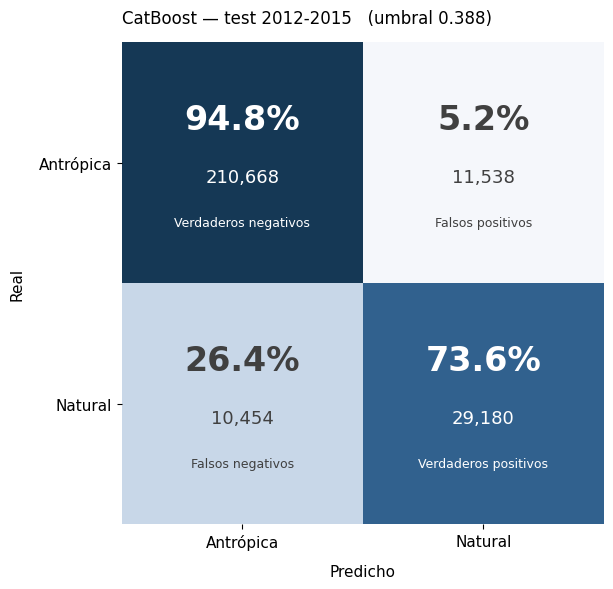

              precision    recall  f1-score   support

   Antrópica     0.9527    0.9481    0.9504    222206
     Natural     0.7166    0.7362    0.7263     39634

    accuracy                         0.9160    261840
   macro avg     0.8347    0.8422    0.8383    261840
weighted avg     0.9170    0.9160    0.9165    261840



In [ ]:
L = LOTES[-1]
tr, va, te = preparar(L['train_fin'], L['test_ini'], L['test_fin'])
cat_idx = [FEATS.index(c) for c in CAT]

modelo_final = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05, l2_leaf_reg=5,
    loss_function='Logloss', eval_metric='PRAUC',
    task_type='GPU', devices='0', cat_features=cat_idx,
    random_seed=SEED, early_stopping_rounds=80, use_best_model=True, verbose=False)
modelo_final.fit(tr[FEATS], tr['ES_NATURAL'], eval_set=(va[FEATS], va['ES_NATURAL']))

p_va = modelo_final.predict_proba(va[FEATS])[:, 1]
UMBRAL = umbral_optimo(va['ES_NATURAL'], p_va)
p_te = modelo_final.predict_proba(te[FEATS])[:, 1]
y_te = te['ES_NATURAL'].values
pred = (p_te >= UMBRAL).astype(int)

cm = confusion_matrix(y_te, pred)
cmp = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cmp, cmap=SEQ, vmin=0, vmax=100)
etiq = [['Verdaderos negativos', 'Falsos positivos'],
        ['Falsos negativos', 'Verdaderos positivos']]
for i in range(2):
    for j in range(2):
        c = 'white' if cmp[i,j] > 55 else '#404040'
        ax.text(j, i - 0.14, f'{cmp[i,j]:.1f}%', ha='center', fontsize=24, fontweight='bold', color=c)
        ax.text(j, i + 0.08, f'{cm[i,j]:,}', ha='center', fontsize=13, color=c)
        ax.text(j, i + 0.26, etiq[i][j], ha='center', fontsize=9, color=c)

ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Antrópica', 'Natural'], fontsize=11)
ax.set_yticklabels(['Antrópica', 'Natural'], fontsize=11)
ax.set_xlabel('Predicho', fontsize=11, labelpad=10)
ax.set_ylabel('Real', fontsize=11, labelpad=10)
ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)

ax.set_title(f'CatBoost — test {L["test_ini"]}-{L["test_fin"]}   (umbral {UMBRAL:.3f})',
             loc='left', pad=14)
plt.tight_layout()
plt.show()

print(classification_report(y_te, pred, target_names=['Antrópica','Natural'], digits=4))

In [ ]:
filas = []
for u in [0.15, 0.20, 0.25, 0.30, UMBRAL, 0.50, 0.60]:
    pr = (p_te >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pr).ravel()
    filas.append({
        'umbral': round(u, 3),
        'Recall (natural detectado)': round(tp/(tp+fn), 3),
        'Precisión': round(tp/(tp+fp), 3),
        'F1': round(f1_score(y_te, pr), 3),
        'Falsos negativos': fn,
        'Falsos positivos': fp,
    })
pd.DataFrame(filas)

,umbral,Recall (natural detectado),Precisión,F1,Falsos negativos,Falsos positivos
0,0.150,0.845,0.582,0.689,6142,24039
1,0.200,0.824,0.617,0.706,6969,20262
2,0.250,0.805,0.646,0.716,7741,17501
3,0.300,0.783,0.673,0.724,8609,15051
4,0.388,0.736,0.717,0.726,10454,11538
5,0.500,0.668,0.770,0.715,13165,7890
6,0.600,0.595,0.814,0.688,16047,5387


Importancia de variables



             Variable  Importancia
        DISCOVERY_DOY    35.739347
            LONGITUDE    18.806576
             LATITUDE    14.310409
                STATE    11.060838
            FIRE_YEAR     7.360371
          OWNER_DESCR     5.686286
NWCG_REPORTING_AGENCY     4.199606
            FIRE_SIZE     2.836566


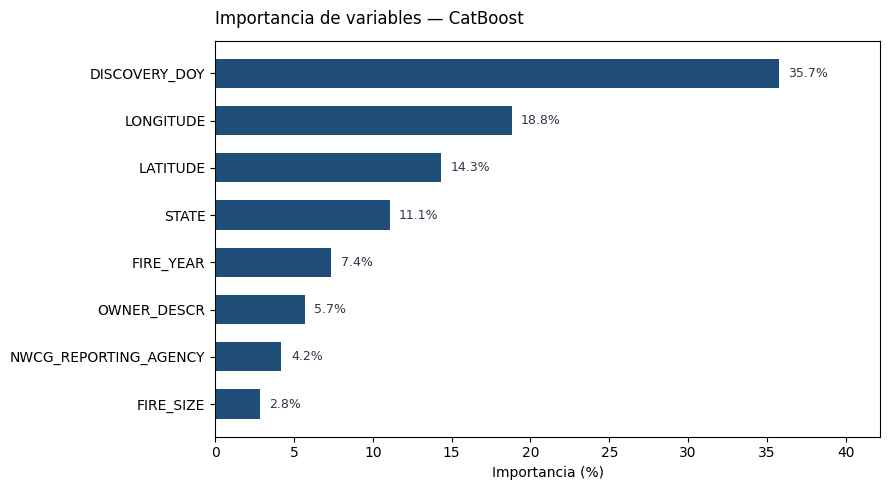

In [ ]:
imp = modelo_final.get_feature_importance(prettified=True)
imp.columns = ['Variable', 'Importancia']
print(imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp['Variable'], imp['Importancia'], color=AZUL, height=0.62)
for i, v in enumerate(imp['Importancia']):
    ax.text(v + 0.6, i, f'{v:.1f}%', va='center', fontsize=9, color=TEXTO)
ax.invert_yaxis()
ax.set_xlim(0, imp['Importancia'].max() * 1.18)
ax.set_xlabel('Importancia (%)')
ax.grid(axis='y', visible=False)
ax.set_title('Importancia de variables — CatBoost', loc='left', pad=12)
plt.tight_layout()
plt.show()

 Análisis SHAP

Los valores SHAP (Lundberg y Lee, 2017) descomponen cada predicción individual en la contribución de cada variable, lo que permite observar no solo la magnitud del efecto sino su dirección: si un valor alto de una variable empuja la predicción hacia causa naturalo hacia causa antrópica.

El cálculo se realiza sobre una muestra de 30.000 observaciones del conjunto de prueba, ya que el procedimiento es computacionalmente costoso.

/tmp/ipykernel_3053/1049559104.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, muestra[FEATS], show=False, max_display=8)


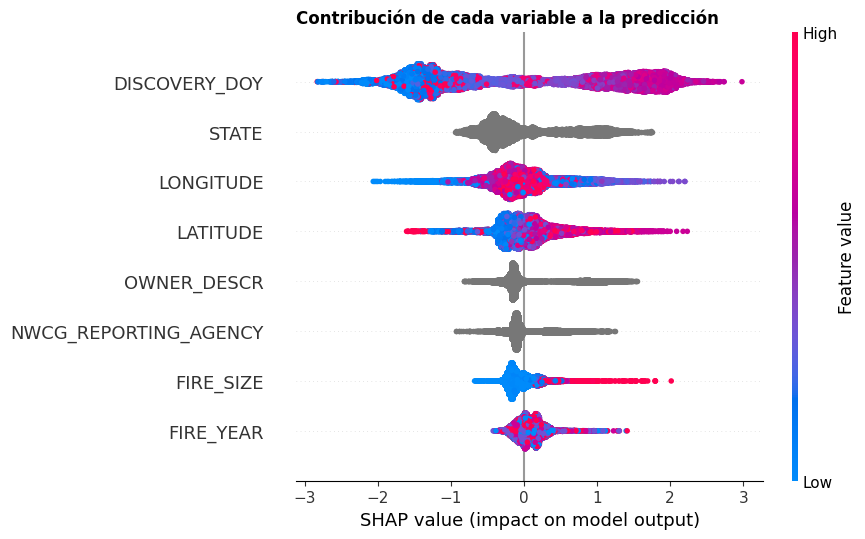

In [ ]:
import shap

muestra = te.sample(30000, random_state=SEED)
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(muestra[FEATS])

shap.summary_plot(shap_values, muestra[FEATS], show=False, max_display=8)
fig = plt.gcf()
fig.set_size_inches(9, 5.5)
plt.title('Contribución de cada variable a la predicción', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

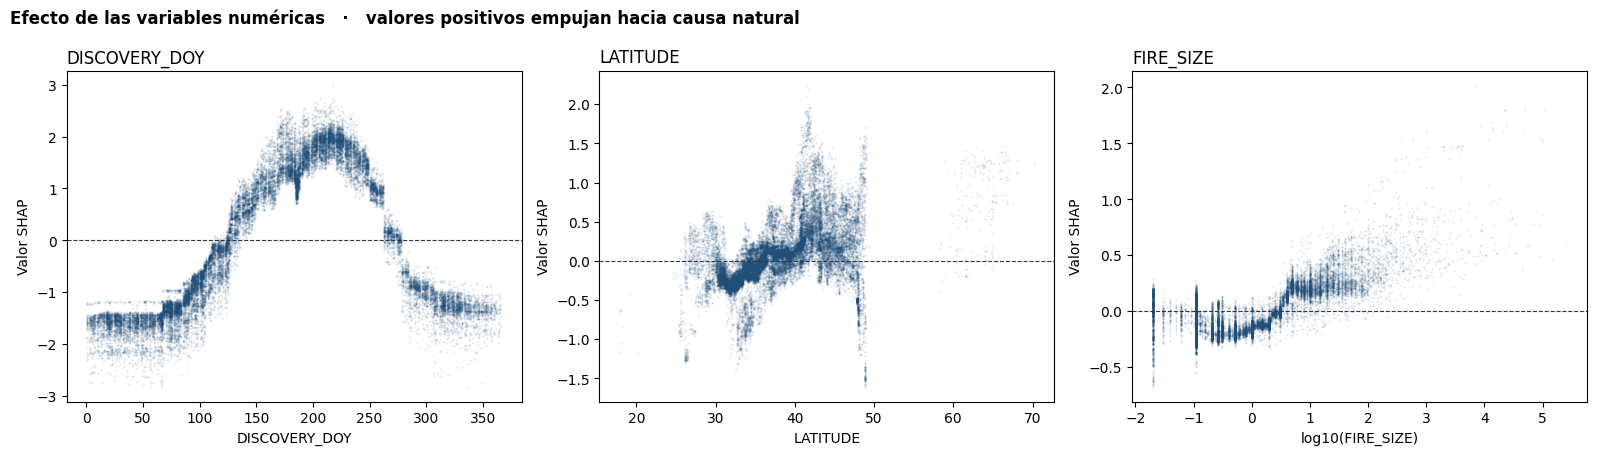

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, var in zip(axes, ['DISCOVERY_DOY', 'LATITUDE', 'FIRE_SIZE']):
    idx = FEATS.index(var)
    x = muestra[var].values
    y = shap_values[:, idx]
    if var == 'FIRE_SIZE':
        x = np.log10(x + 0.01)
        ax.set_xlabel('log10(FIRE_SIZE)')
    else:
        ax.set_xlabel(var)
    ax.scatter(x, y, s=2, alpha=0.15, color=AZUL, linewidths=0)
    ax.axhline(0, color=TEXTO, lw=0.8, ls='--')
    ax.set_ylabel('Valor SHAP')
    ax.set_title(var, loc='left')

fig.suptitle('Efecto de las variables numéricas   ·   valores positivos empujan hacia causa natural',
             x=0.005, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Curvas ROC y precisión-recall


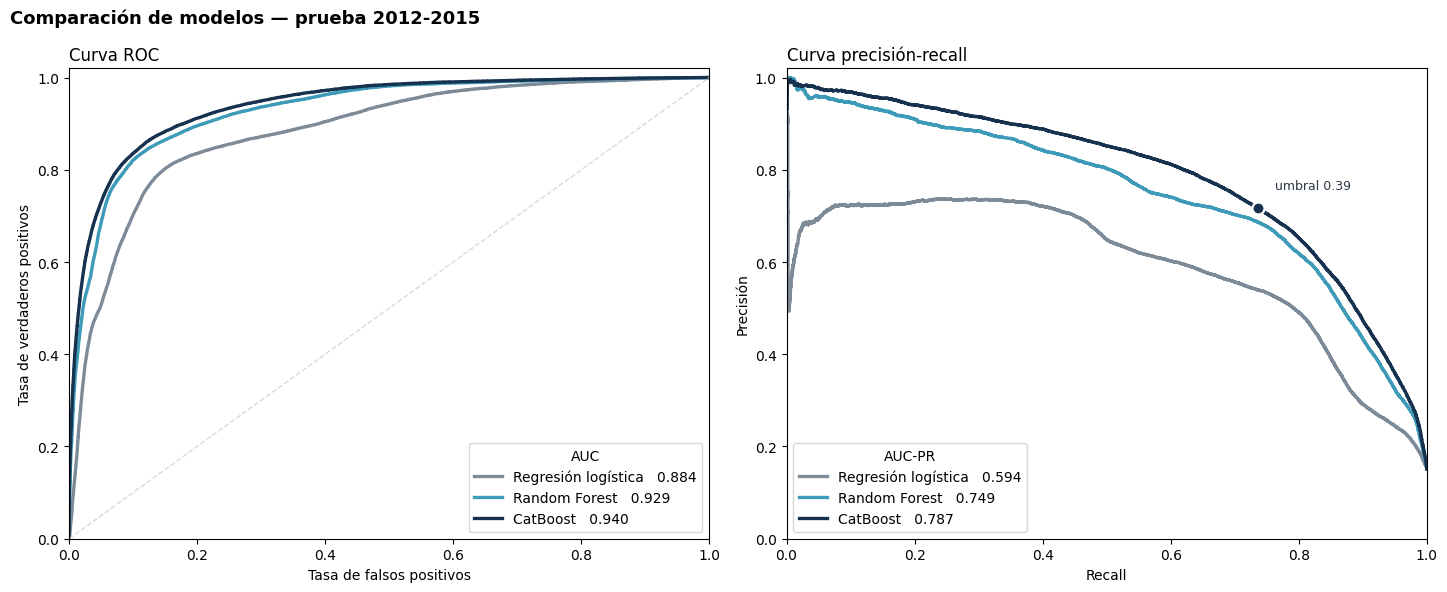

In [ ]:
GRAFITO = '#7d8b99'
CELESTE = '#3d9ab8'
MARINO  = '#16324f'

tr4, va4, te4 = preparar(LOTES[-1]['train_fin'], LOTES[-1]['test_ini'], LOTES[-1]['test_fin'])
y4 = te4['ES_NATURAL'].values

pipe_lr = Pipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), CAT)])),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
])
pipe_lr.fit(tr4[FEATS], tr4['ES_NATURAL'])
p_lr = pipe_lr.predict_proba(te4[FEATS])[:, 1]

tr4_s = tr4.sample(frac=0.30, random_state=SEED)
pipe_rf = Pipeline([
    ('prep', ColumnTransformer([
        ('num', 'passthrough', NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), CAT)])),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=18, min_samples_leaf=20,
                                   class_weight='balanced', random_state=SEED, n_jobs=-1))
])
pipe_rf.fit(tr4_s[FEATS], tr4_s['ES_NATURAL'])
p_rf = pipe_rf.predict_proba(te4[FEATS])[:, 1]

p_cb = p_te

curvas = [('Regresión logística', p_lr, GRAFITO),
          ('Random Forest', p_rf, CELESTE),
          ('CatBoost', p_cb, MARINO)]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6))

ax = axes[0]
for nombre, p, color in curvas:
    fpr, tpr, _ = roc_curve(y4, p)
    ax.plot(fpr, tpr, color=color, lw=2.4,
            label=f'{nombre}   {roc_auc_score(y4, p):.3f}')
ax.plot([0, 1], [0, 1], color='#d5dbe0', lw=1, ls='--')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curva ROC', loc='left')
ax.legend(loc='lower right', title='AUC')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

ax = axes[1]
for nombre, p, color in curvas:
    prec, rec, _ = precision_recall_curve(y4, p)
    ax.plot(rec, prec, color=color, lw=2.4,
            label=f'{nombre}   {average_precision_score(y4, p):.3f}')

rec_u = recall_score(y4, (p_cb >= UMBRAL).astype(int))
prec_u = precision_score(y4, (p_cb >= UMBRAL).astype(int))
ax.scatter([rec_u], [prec_u], s=75, color=MARINO, zorder=5,
           edgecolor='white', linewidth=1.6)
ax.annotate(f'umbral {UMBRAL:.2f}', xy=(rec_u, prec_u),
            xytext=(12, 14), textcoords='offset points', fontsize=9, color=TEXTO)

ax.set_xlabel('Recall')
ax.set_ylabel('Precisión')
ax.set_title('Curva precisión-recall', loc='left')
ax.legend(loc='lower left', title='AUC-PR')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

fig.suptitle('Comparación de modelos — prueba 2012-2015',
             x=0.005, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Análisis de errores

Se busca la distribución de los errores según la ubicación, el momento del año y la magnitud del incendio, con el objetivo de identificar si existen condiciones sistemáticas en las que el modelo pierde capacidad predictiva.

In [ ]:
err = te4.copy()
err['proba'] = p_cb
err['pred'] = (p_cb >= UMBRAL).astype(int)
err['acierto'] = (err['pred'] == err['ES_NATURAL']).astype(int)
err['tipo_error'] = np.select(
    [(err['ES_NATURAL']==1) & (err['pred']==0),
     (err['ES_NATURAL']==0) & (err['pred']==1)],
    ['Falso negativo', 'Falso positivo'], default='Correcto')

print(f"Aciertos: {err['acierto'].mean()*100:.2f}%")
print()
print(err['tipo_error'].value_counts().to_string())

Aciertos: 91.60%

tipo_error
Correcto          239848
Falso positivo     11538
Falso negativo     10454


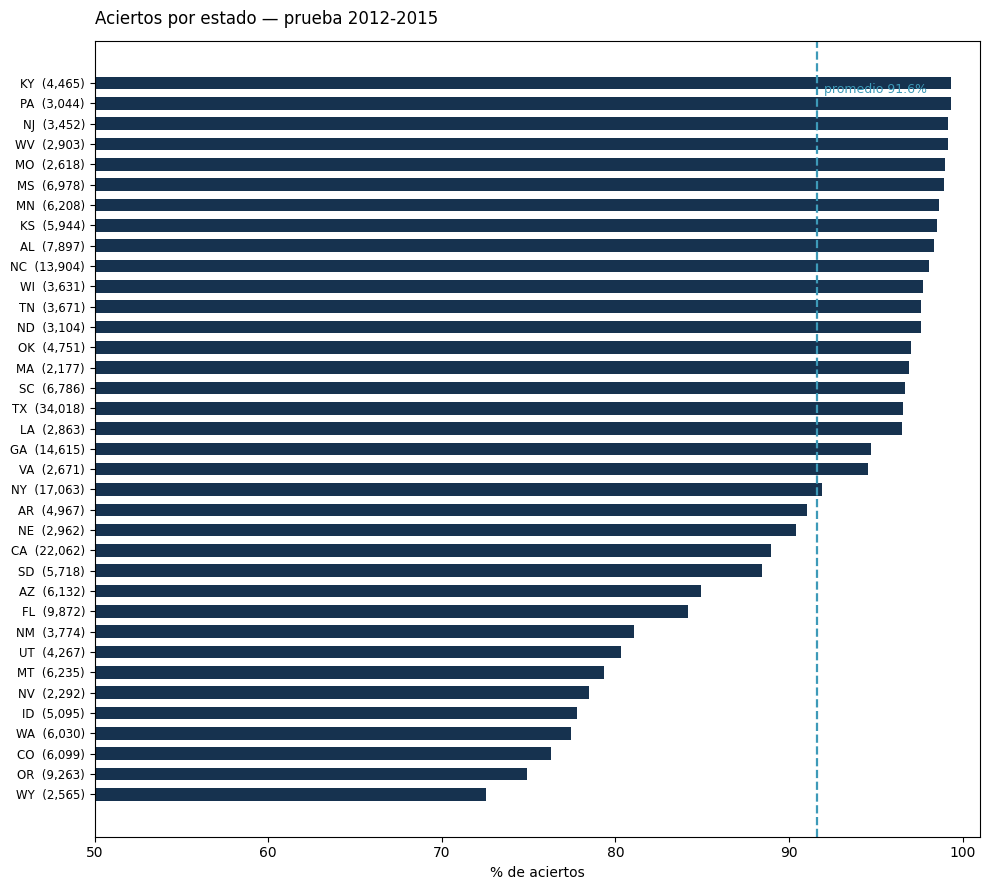

In [ ]:
est = err.groupby('STATE').agg(
    n=('acierto','size'), acc=('acierto','mean'), nat=('ES_NATURAL','mean')).reset_index()
est = est[est['n'] > 2000].sort_values('acc')

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(range(len(est)), est['acc']*100, color=MARINO, height=0.62)
ax.set_yticks(range(len(est)))
ax.set_yticklabels([f"{s}  ({n:,})" for s, n in zip(est['STATE'], est['n'])], fontsize=8.5)
ax.axvline(err['acierto'].mean()*100, color=CELESTE, lw=1.6, ls='--')
ax.text(err['acierto'].mean()*100 + 0.4, len(est)-1.5,
        f"promedio {err['acierto'].mean()*100:.1f}%", fontsize=9, color=CELESTE)
ax.set_xlim(50, 101)
ax.set_xlabel('% de aciertos')
ax.grid(axis='y', visible=False)
ax.set_title('Aciertos por estado — prueba 2012-2015', loc='left', pad=12)
plt.tight_layout()
plt.show()

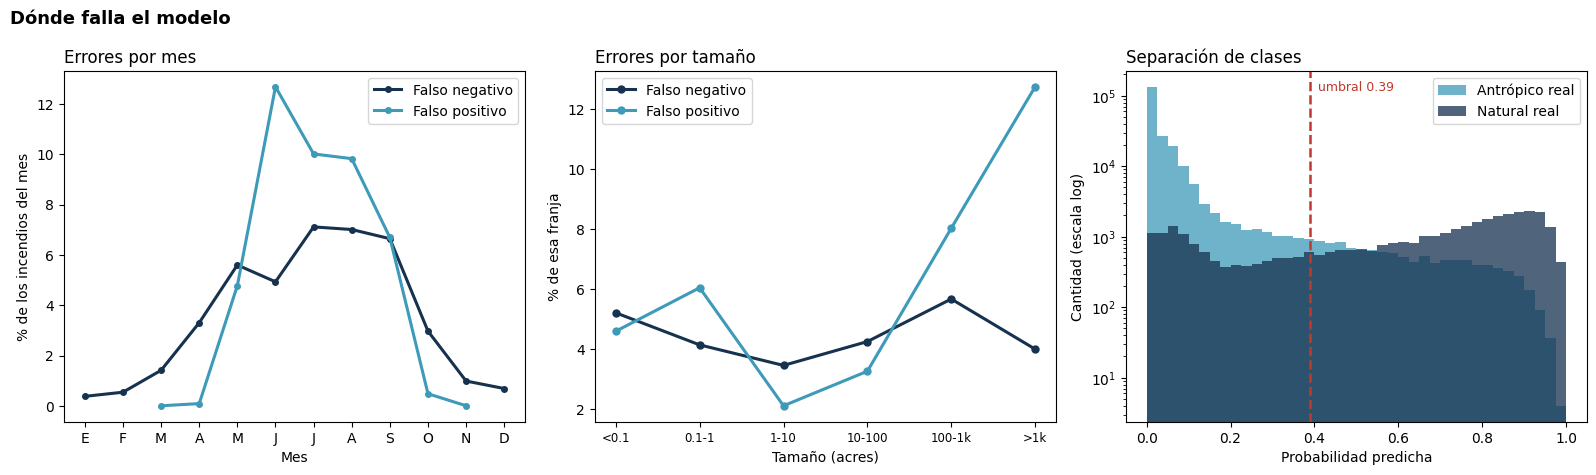

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
m = pd.to_datetime(err['DISCOVERY_DOY'], format='%j').dt.month
for tipo, color in [('Falso negativo', MARINO), ('Falso positivo', CELESTE)]:
    sub = err[err['tipo_error']==tipo]
    tasa = sub.groupby(pd.to_datetime(sub['DISCOVERY_DOY'], format='%j').dt.month).size() / err.groupby(m).size() * 100
    ax.plot(tasa.index, tasa.values, color=color, lw=2.2, marker='o', ms=4, label=tipo)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_xlabel('Mes'); ax.set_ylabel('% de los incendios del mes')
ax.set_title('Errores por mes', loc='left')
ax.legend()

ax = axes[1]
cl = pd.crosstab(err['FIRE_SIZE_CLASS'] if 'FIRE_SIZE_CLASS' in err else
                 pd.cut(np.log10(err['FIRE_SIZE']+0.01), bins=[-3,-1,0,1,2,3,7],
                        labels=['<0.1','0.1-1','1-10','10-100','100-1k','>1k']),
                 err['tipo_error'], normalize='index') * 100
for tipo, color in [('Falso negativo', MARINO), ('Falso positivo', CELESTE)]:
    if tipo in cl:
        ax.plot(range(len(cl)), cl[tipo], color=color, lw=2.2, marker='o', ms=5, label=tipo)
ax.set_xticks(range(len(cl))); ax.set_xticklabels(cl.index, fontsize=8.5)
ax.set_xlabel('Tamaño (acres)'); ax.set_ylabel('% de esa franja')
ax.set_title('Errores por tamaño', loc='left')
ax.legend()

ax = axes[2]
bins = np.linspace(0, 1, 41)
ax.hist(err[err['ES_NATURAL']==0]['proba'], bins=bins, color=CELESTE, alpha=0.75, label='Antrópico real')
ax.hist(err[err['ES_NATURAL']==1]['proba'], bins=bins, color=MARINO, alpha=0.75, label='Natural real')
ax.axvline(UMBRAL, color='#c0392b', lw=1.8, ls='--')
ax.text(UMBRAL+0.02, ax.get_ylim()[1]*0.85, f'umbral {UMBRAL:.2f}', fontsize=9, color='#c0392b')
ax.set_yscale('log')
ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Cantidad (escala log)')
ax.set_title('Separación de clases', loc='left')
ax.legend()

fig.suptitle('Dónde falla el modelo', x=0.005, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()